### **P P3. Aprendizaje no supervisado**
---

En 2022, hubo 420,368 nuevos casos de cáncer de endometrio, de acuerdo con World Cancer Research Fund (2025).


El cáncer de endometrio es el cuarto más común entre las mujeres en los Estados Unidos, según American Cancer Society (s.f.). Este tipo de cáncer comienza cuando las células en el endometrio comienzan a multiplicarse de forma descontrolada. Este tipo de cáncer no debe confundirse con el cáncer de cuello uterino.


Los síntomas del cáncer de endometrio pueden incluir:
- Sangrado vaginal después de la menopausia.
- Sangrado entre periodos menstruales.
- Dolor pélvico.


(Mayo Clinic, s. f.)


Aunque aún no se descubre una causa de este tipo de cáncer, hay ciertos factores que pueden aumentar el riesgo de padecer cáncer de este tipo, que se mencionan a continuación:


- Cambios en el equilibrio hormonal del organismo
- Más años de menstruación
- Nunca haber tenido un embarazo
- Edad avanzada
- Obesidad
- Terapia hormonal para cáncer de mama
- Un síndrome hereditario que aumenta el riesgo para cáncer


(Mayo Clinic, s. f.)


Debido al impacto de este tipo de cáncer en la población femenina y que aún no se puede explicar completamente la causa de éste, resulta importante explorar los casos ya existentes para poder encontrar patrones o posibles causas de esta problemática. Por lo tanto, este proyecto tiene como objetivo identificar posibles agrupaciones basadas en la expresión genética y posteriormente interpretar estos grupos de variables clínicas con el fin de aportar evidencia que ayude a explicar la variabilidad presente en el cáncer de endometrio.


---


Los datos que se utilizan en este proyecto provienen de The Cancer Genome Atlas (TCGA), los cuales fueron tomados a través de la plataforma UCSC XENA. Para este caso, se seleccionó la cohorte GDC TCGA UCEC, la cual corresponde al cáncer endometrial.


Se tienen 2 tipos principales de información. Por un lado, se tienen los datos de expresión génica (`RNA-seq`), los cuales contienen los niveles de expresión genética de miles de genes para cada muestra de tumor. Además, se hará uso de los datos clínicos (`phenotype`), en donde se incluyen variables relevantes del paciente (como edad, estado clínico, etc.), al igual que se hizo uso de los datos de supervivencia, ya que sí estaban disponibles en la página.


Con los datos de expresión génica, se aplicarán técnicas de clustering no supervisado sobre la expresión génica para poder identificar posibles grupos. Posteriormente, estos grupos serán analizados en función de las variables clínicas para ver si los patrones identificados sí tienen alguna coherencia y se puede aplicar algo en la vida real.


---


Para comenzar viendo las características de los datos que se usarán, se cargarán al espacio de trabajo usando la librería `pandas`, e importando el archivo con `read`. Por ahora, sólo se trabaja con los datos genéticos. Luego, se imprimen las primeras 5 filas de los datos con `head()`. Para conocer las dimensiones de los datos con los que se estarán trabajando, se usa la función `shape`.













In [ ]:
import pandas as pd

# Load the RNA-seq expression data
rna_seq_df = pd.read_csv('/content/TCGA-UCEC.star_tpm.tsv.gz', sep='\t')

# Display the first 5 rows of the DataFrame
print('RNA-seq expression data (first 5 rows):')
display(rna_seq_df.head())
print('Dimensiones de la base de datos: ', rna_seq_df.shape)

RNA-seq expression data (first 5 rows):


,Ensembl_ID,TCGA-FI-A3PX-01A,TCGA-BG-A221-01A,TCGA-EY-A1GK-01A,TCGA-BG-A2AE-01A,TCGA-AX-A1CE-01A,TCGA-DI-A2QY-01A,TCGA-D1-A1O8-01A,TCGA-EY-A3QX-01A,TCGA-DI-A0WH-01A,...,TCGA-E6-A1LX-01A,TCGA-FI-A3PV-01A,TCGA-BG-A0MT-01A,TCGA-EY-A549-01A,TCGA-D1-A1O7-01A,TCGA-AJ-A3NF-01A,TCGA-BK-A0C9-01A,TCGA-AJ-A5DW-01A,TCGA-AP-A05J-01A,TCGA-D1-A103-01A
0,ENSG00000000003.15,6.591445,5.483593,5.569616,5.567250,6.887587,6.642866,3.860665,5.520353,5.337290,...,4.857563,6.407465,6.599611,5.898457,6.209582,6.694986,5.275748,6.882687,5.399168,5.770443
1,ENSG00000000005.6,0.394734,0.000000,0.201759,0.468218,0.921589,0.052138,0.753605,0.301471,0.274888,...,0.129876,0.000000,0.265677,0.052138,0.107956,0.196481,0.142609,0.403377,0.999856,0.107152
2,ENSG00000000419.13,7.515168,6.029596,5.825315,5.738738,6.328880,5.967869,5.306991,5.870520,4.538737,...,6.385633,6.833120,6.355259,6.460367,5.829857,6.632550,4.397789,7.062093,4.534890,5.799124
3,ENSG00000000457.14,2.521955,2.407978,3.249840,2.812087,2.644779,1.747989,2.296604,2.951718,2.766765,...,2.681427,2.693230,3.512012,3.586092,2.153708,2.951327,2.625341,3.244156,1.391383,2.827921
4,ENSG00000000460.17,3.032260,2.382114,1.831999,1.869635,1.788226,1.358678,1.687867,3.251492,1.997220,...,2.395858,2.304044,3.133399,1.629613,1.971038,2.702658,2.339052,3.142479,1.539432,2.166137


Dimensiones de la base de datos:  (60660, 586)


Se puede observar que hay 60,660 filas (que son los genes) y 586 columnas (que son los pacientes). También se puede observar que hay una columna llamada `Ensembl_ID`, donde cada fila de esta columna es un gen diferente. Luego, se tiene las columnas que inicia con `TCGA-...`, que cada columna corresponde a un paciente diferente. Los niveles que se encuentran en esta tabla con niveles de expresión genética (TPM -> Transcripts Per Million), donde se indica qué tanto se expresa cada gen en cada paciente.


Como se puede observar, la estructura de la tabla con los datos no es la convencional, ya que las observaciones se tienen como columnas en vez de filas. Debido a la practicidad en la ejecución de los siguientes procesos, se hará una transformación de los datos. Se va a transponer el DataFrame, para que las filas ahora queden en el lugar de las columnas. Además, se deberá cambiar los nombres de las columnas y de filas. Esto se hará con `.T`. Después se imprimen los datos para confirmar que se haya realizado este paso correctamente.







In [ ]:
rna_seq_df_transposed = rna_seq_df.set_index('Ensembl_ID').T

print('RNA-seq expression data (first 5 rows after transposition):')
display(rna_seq_df_transposed.head())
print('Dimensiones de la base de datos transpuesta: ', rna_seq_df_transposed.shape)

RNA-seq expression data (first 5 rows after transposition):


Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-FI-A3PX-01A,6.591445,0.394734,7.515168,2.521955,3.032260,1.361656,2.317130,6.681728,3.693286,6.319491,...,0.0,0.000000,0.672561,0.0,0.0,0.000000,4.176099,0.0,0.077516,1.389347
TCGA-BG-A221-01A,5.483593,0.000000,6.029596,2.407978,2.382114,3.643475,3.093729,6.434083,3.206924,5.208045,...,0.0,0.000000,0.575700,0.0,0.0,0.043345,2.529621,0.0,0.071076,2.113334
TCGA-EY-A1GK-01A,5.569616,0.201759,5.825315,3.249840,1.831999,2.693610,2.105477,5.833100,3.116498,4.727300,...,0.0,1.508936,0.473735,0.0,0.0,0.000000,2.369634,0.0,0.032806,1.963807
TCGA-BG-A2AE-01A,5.567250,0.468218,5.738738,2.812087,1.869635,3.134467,3.545190,5.884097,2.446044,5.543134,...,0.0,0.000000,0.200379,0.0,0.0,0.000000,3.022421,0.0,0.082430,2.154778
TCGA-AX-A1CE-01A,6.887587,0.921589,6.328880,2.644779,1.788226,2.456254,2.864909,7.280138,4.543100,4.442585,...,0.0,0.000000,0.741230,0.0,0.0,0.000000,3.895060,0.0,0.019631,2.717605


Dimensiones de la base de datos transpuesta:  (585, 60660)


Ahora que ya se tienen los datos en el formato deseado, observaciones (pacientes) como filas y características (genes) como columnas, se hará un análisis para encontrar los valores faltantes, valores atípicos y un análisis básico de la distribución de los datos. Para los valores faltantes, se hará sumando todas las celdas donde haya un valor nulo. Si esta suma es mayor a 0, entonces significa que sí hay valores faltantes, de lo contrario la base de datos está completa. Se utilizará un `for` loop para poder identificar esto, imprimiendo un mensaje para mostrar lo que se encontró.


In [ ]:
# Check for missing values in the transposed DataFrame
print('\nMissing values per column in transposed DataFrame:')
missing_values_transposed = rna_seq_df_transposed.isnull().sum()
display(missing_values_transposed[missing_values_transposed > 0])

if missing_values_transposed.sum() == 0:
    print('\nNo missing values found in the transposed DataFrame.')
else:
    print(f'\nTotal missing values found in transposed DataFrame: {missing_values_transposed.sum()}')


Missing values per column in transposed DataFrame:


,0
Ensembl_ID,



No missing values found in the transposed DataFrame.


De acuerdo con esta prueba, no se encontraron valores faltantes.
Ahora, se imprimirá una tabla descriptiva con datos estadísticos sobre las variables.
Para esto se usa la función `describe`.

In [ ]:
# Basic distribution analysis (descriptive statistics for expression values in transposed DataFrame)
print('\nDescriptive statistics for transposed RNA-seq expression data:')
display(rna_seq_df_transposed.describe())


Descriptive statistics for transposed RNA-seq expression data:


Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
count,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,585.000000,...,585.0,585.000000,585.000000,585.0,585.000000,585.000000,585.000000,585.0,585.000000,585.000000
mean,5.896136,0.344331,6.021694,2.808660,2.229152,2.643888,3.344726,6.079241,3.656350,4.884641,...,0.0,0.395673,0.453400,0.0,0.351905,0.006180,2.898863,0.0,0.068178,1.437893
std,0.854575,0.736188,0.936023,0.679828,0.818300,0.974714,1.496058,0.591129,1.026485,0.757236,...,0.0,0.882212,0.238726,0.0,0.870022,0.033081,0.725384,0.0,0.049925,0.587673
min,2.181389,0.000000,1.341473,0.876566,0.231432,0.498353,0.232538,3.973170,0.903655,2.676177,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.777199,0.0,0.000000,0.124990
25%,5.401439,0.000000,5.572996,2.383552,1.596601,1.952781,2.138356,5.693342,3.040086,4.374365,...,0.0,0.000000,0.288063,0.0,0.000000,0.000000,2.458566,0.0,0.032242,1.038296
50%,6.029906,0.135404,6.153974,2.798403,2.228634,2.636033,3.165140,6.122646,3.578371,4.898281,...,0.0,0.000000,0.419377,0.0,0.000000,0.000000,2.930075,0.0,0.059217,1.422341
75%,6.542048,0.351967,6.633858,3.209718,2.803392,3.238038,4.446627,6.504009,4.129267,5.380491,...,0.0,0.000000,0.590434,0.0,0.000000,0.000000,3.421493,0.0,0.098958,1.823423
max,7.957309,8.893252,8.528754,5.043371,4.715827,6.654132,7.834434,7.709046,8.009597,6.895849,...,0.0,5.788088,1.463675,0.0,6.729164,0.619272,4.843285,0.0,0.280362,3.649627


Debido a que son muchas variables, sólo se imprimen los cálculos estadísticos para algunas. De las que se imprimen, se puede observar que muchas de los genes tienen expresiones con máximos mayores a 4 y mínimos de 0.


Ahora, se hará una búsqueda de posibles valores atípicos. Se aplicará el método del rango intercuartil. Este método define los valores atípicos como aquellos que caen por debajo de $Q1 - 1.5 \times IQR$ o por encima de $Q3 + 1.5 \times IQR$, donde $Q1$ es el primer cuartil, $Q3$ es el tercer cuartil, e $IQR = Q3 - Q1$. Se aplicará este método a todas las columnas, para todos sus valores. Primero se hacen los cálculos de los cuartiles a utilizar, con `quantile(n)`, donde `n`el porcentaje del cuartil que se está buscando. Después se calcula `IQR` haciendo la resta. Después se definen los límites inferiores y superiores, con la fórmula anteriormente mencionada. Posteriormente se identifican los valores que queden fuera de este rango y se imprimen.





In [ ]:
# Flatten the DataFrame to analyze the distribution of all expression values
all_expression_values = rna_seq_df_transposed.stack()

# Calculate Q1, Q3, and IQR
Q1 = all_expression_values.quantile(0.25)
Q3 = all_expression_values.quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = all_expression_values[(all_expression_values < lower_bound) | (all_expression_values > upper_bound)]

print(f'Primer Cuartil (Q1): {Q1:.4f}')
print(f'Tercer Cuartil (Q3): {Q3:.4f}')
print(f'Rango Intercuartílico (IQR): {IQR:.4f}')
print(f'Límite Inferior para valores atípicos: {lower_bound:.4f}')
print(f'Límite Superior para valores atípicos: {upper_bound:.4f}')
print(f'\nNúmero total de valores de expresión: {len(all_expression_values)}')
print(f'Número de valores atípicos detectados: {len(outliers)}')

if not outliers.empty:
    print('\nAlgunos ejemplos de valores atípicos:')
    display(outliers.sample(min(5, len(outliers)))) # Display up to 5 random outliers
else:
    print('\nNo se detectaron valores atípicos según el método IQR en la distribución general de expresión.')


Primer Cuartil (Q1): 0.0000
Tercer Cuartil (Q3): 1.4257
Rango Intercuartílico (IQR): 1.4257
Límite Inferior para valores atípicos: -2.1385
Límite Superior para valores atípicos: 3.5642

Número total de valores de expresión: 35486100
Número de valores atípicos detectados: 4728947

Algunos ejemplos de valores atípicos:


,,0
,Ensembl_ID,
TCGA-AP-A0LD-01A,ENSG00000203485.14,5.314816
TCGA-AX-A0IZ-11A,ENSG00000134250.20,5.082030
TCGA-A5-A0GU-01A,ENSG00000182326.15,6.363635
TCGA-D1-A16R-01A,ENSG00000110042.8,4.090295
TCGA-SJ-A6ZJ-01A,ENSG00000234745.12,10.802395


Como se puede observar, se encontraron 4728947 valores atípicos. Sin embargo, de acuerdo con EBI Functional Genomics Team (s.f.) dice que el nivel de expresión puede ir desde 0 hasta 1000 TPM. Por lo que realmente estos posibles valores atípicos sí están dentro del rango permitido para este tipo de datos. Debido a esto, se conservarán todos los datos.


Ahora, se prepararán los datos para poder aplicar la metodología para encontrar posibles clusters.
Debido a que se va a hacer uso de PCA se normalizarán los datos primero. Esto se debe hacer ya que PCA maximiza la varianza para construir los componentes principales. Si no se normalizan los datos y se tiene escalas muy distintas, entonces se le podría dar mayor peso a variables que puede que no estén explicando gran parte de la información, sino que solamente tienen escalas muy grandes. Para esto, se usa la función `StandardScaler`, que transforma los datos para que tengan una media de 0 y una desviación estándar de 1. Para usar esta función se necesita importar la librería del mismo nombre. Luego se imprimen los valores de la nueva base de datos ya normalizada con `display`.









In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Normalize the transposed DataFrame
# Convert to numpy array first for scaling, then back to DataFrame
rna_seq_scaled = scaler.fit_transform(rna_seq_df_transposed)

# Convert the scaled array back to a DataFrame
rna_seq_scaled_df = pd.DataFrame(rna_seq_scaled, columns=rna_seq_df_transposed.columns, index=rna_seq_df_transposed.index)

print('RNA-seq data after StandardScaler (first 5 rows):')
display(rna_seq_scaled_df.head())
print('Dimensiones de la base de datos normalizada: ', rna_seq_scaled_df.shape)

RNA-seq data after StandardScaler (first 5 rows):


Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-FI-A3PX-01A,0.814328,0.068524,1.596920,-0.422092,0.982274,-1.316622,-0.687456,1.020087,0.036014,1.896475,...,0.0,-0.448884,0.918829,0.0,-0.404824,-0.186974,1.762279,0.0,0.187216,-0.082679
TCGA-BG-A221-01A,-0.483159,-0.468121,0.008450,-0.589891,0.187086,1.026397,-0.167915,0.600793,-0.438205,0.427451,...,0.0,-0.448884,0.512738,0.0,-0.404824,1.124400,-0.509465,0.0,0.058105,1.150332
TCGA-EY-A1GK-01A,-0.382412,-0.193827,-0.209981,0.649514,-0.485755,0.051056,-0.829052,-0.416747,-0.526373,-0.207962,...,0.0,1.262980,0.085253,0.0,-0.404824,-0.186974,-0.730209,0.0,-0.709106,0.895676
TCGA-BG-A2AE-01A,-0.385182,0.168427,-0.302554,0.005046,-0.439723,0.503737,0.134110,-0.330402,-1.180087,0.870345,...,0.0,-0.448884,-1.060788,0.0,-0.404824,-0.186974,0.170480,0.0,0.285721,1.220915
TCGA-AX-A1CE-01A,1.161163,0.784789,0.328463,-0.241268,-0.539293,-0.192666,-0.320995,2.033271,0.864609,-0.584275,...,0.0,-0.448884,1.206721,0.0,-0.404824,-0.186974,1.374512,0.0,-0.973237,2.179457


Dimensiones de la base de datos normalizada:  (585, 60660)


Como se puede observar en la tabla anterior, los valores ya quedaron normalizados, ya que ahora se tienen valores negativos que antes no se tenían. Debido a que son muchas variables, se aplicará PCA para poder reducir la dimensionalidad de la base de datos, seleccionando la cantidad de componentes utilizando la varianza explicada acumulada.


Para aplicar PCA, se usará la función y librería del mismo nombre. Para poder realizar ciertas operaciones matemáticas, se importará la librería `numpy`. Para las gráficas, las librería `matplotlib.pyplot` deberá ser importada. Se inicializa PCA sin especificar un número de componentes, y luego se ajusta a los datos transpuestos escalados que se tienen, usando la función `pca.fit`. Después, con un `for` loop se va obteniendo la varianza explicada para cada componente, con la función `explained_variance_ratio`. Después de eso, se grafican estos valores que se acaban de obtener, para tener una mejor visualización de cómo va cambiando la varianza que explica cada componente. Esto se haec con `plt.bar`, ya que se usará un gráfico de barras. Luego, para graficar la varianza explicada acumulada primero se hace una suma de la varianza explicada individual y después se grafica con `plt.plot`. A ambos gráficos se le añaden títulos de ejes y de gráfica para una mejor interpretación. Por último, se imprimen la cantidad de componentes necesarios para conservar cierto porcentaje de varianza (805, 85%, 90%, 95%, 99%). Esto se hace para poder hacer un análisis de qué tantos componentes conviene tomar considerando el porcentaje que explican sobre los datos. Además, se imprime la cantidad de componentes que fueron generados para tener este dato, ya que al inicio no se estableció un parámetro con un límite.





Varianza explicada por cada componente principal (primeros 10):
Componente 1: 0.1478
Componente 2: 0.0701
Componente 3: 0.0412
Componente 4: 0.0288
Componente 5: 0.0253
Componente 6: 0.0235
Componente 7: 0.0201
Componente 8: 0.0165
Componente 9: 0.0134
Componente 10: 0.0122


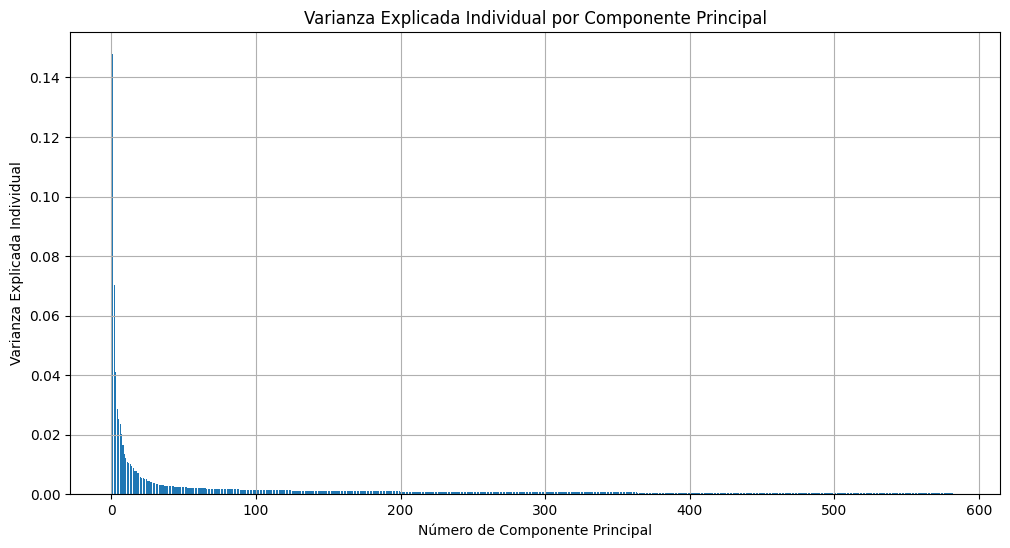

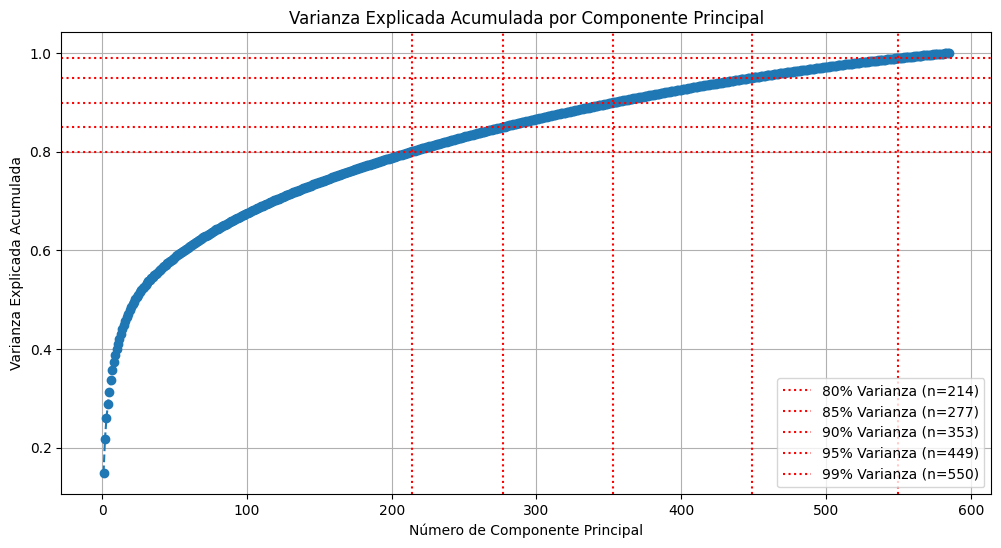


Número de componentes necesarios para retener la varianza:
80% de la varianza: 214 componentes
85% de la varianza: 277 componentes
90% de la varianza: 353 componentes
95% de la varianza: 449 componentes
99% de la varianza: 550 componentes
La cantidad total de componentes principales es: 585


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Initialize PCA without specifying n_components to get all components
pca = PCA()

# Fit PCA on the scaled data
pca.fit(rna_seq_scaled_df)

# Get explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

print('Varianza explicada por cada componente principal (primeros 10):')
for i, ratio in enumerate(explained_variance_ratio[:10]):
    print(f'Componente {i+1}: {ratio:.4f}')

# Plotting individual explained variance
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.xlabel('Número de Componente Principal')
plt.ylabel('Varianza Explicada Individual')
plt.title('Varianza Explicada Individual por Componente Principal')
plt.grid(True)
plt.show()

# Plotting cumulative explained variance
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Varianza Explicada Acumulada por Componente Principal')
plt.grid(True)

# Add lines for desired variance levels
for threshold in [0.80, 0.85, 0.90, 0.95, 0.99]:
    num_components = np.argmax(cumulative_explained_variance >= threshold) + 1
    plt.axvline(x=num_components, color='r', linestyle=':', label=f'{threshold*100:.0f}% Varianza (n={num_components})')
    plt.axhline(y=threshold, color='r', linestyle=':')

plt.legend()
plt.show()

# Print the number of components for specific variance retention levels
print('\nNúmero de componentes necesarios para retener la varianza:')
for threshold in [0.80, 0.85, 0.90, 0.95, 0.99]:
    num_components = np.argmax(cumulative_explained_variance >= threshold) + 1
    print(f'{threshold*100:.0f}% de la varianza: {num_components} componentes')

total_components = len(explained_variance_ratio)
print(f'La cantidad total de componentes principales es: {total_components}')


Como se puede ver, tanto en las gráficas, como en los valores impresos, el primer componente es el que más varianza explica y conforme va aumentando el número de componente, la varianza explicada por éste disminuye.


Con 449 componentes se puede explicar el 95% de la varianza de los datos. Con 353 componentes se puede explicar el 90% de la varianza de los datos. Se crearon 585 componentes, ya que aunque se tienen más variables, el número máximo de componentes principales que se pueden extraer de un conjunto de datos siempre es el mínimo entre el número de filas (pacientes) y número de características (tipo de gen). Considerando que se necesitan 353 componentes para explicar el 90% de la varianza podría indicar que los datos del conjunto están distribuidos en muchas variables, en lugar de concentrarse en algunas cuantas. Esto podría apuntar que los datos son complejos y no pueden resumirse fácilmente. Por esto mismo, la reducción de dimensionalidad no es tan agresiva, a que se pasa de tener 585 datos a 353, la cual sigue siendo una dimensión alta.


Se opta usar el umbral de 90% de la varianza en lugar del 95% o 99% ya que el incremento de componentes necesarios (aproximadamente unos 100 componentes) no compensa lo que se gana en varianza explicada.


Ahora se harán gráficas 2D para los primeros componentes para ver si qué tan clara es la distinción entre los datos y ver si hay posibles clusters. Sin embargo, considerando lo anterior, 2 o 3 componentes no servirán de mucho para ver este tipo de clasificaciones. Para hacer esto, se vuelve a hacer el procedimiento de PCa pero ahora sí agregando el parámetro para definir el número de componentes con `n_components=3`. Después de eso, se hacen las gráficas; se graficará el componente 1 vs el 2, luego el 2 vs el 3 y por último el 1 vs el 3. Esto se hace con la función `scatter`. A todos los gráficos se le añaden títulos de ejes y de gráficas para mayor comprensión.







In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Re-initialize PCA with the selected number of components (353 for 90% variance)
# Although the previous text suggests 353, for 2D plots, we only need a few components
# Let's re-run PCA to get enough components to plot the first 3

pca_plot = PCA(n_components=3)
principal_components = pca_plot.fit_transform(rna_seq_scaled_df)

# Create a DataFrame for the principal components for easier plotting
pc_df = pd.DataFrame(data = principal_components, columns = ['Componente 1', 'Componente 2', 'Componente 3'], index=rna_seq_scaled_df.index)



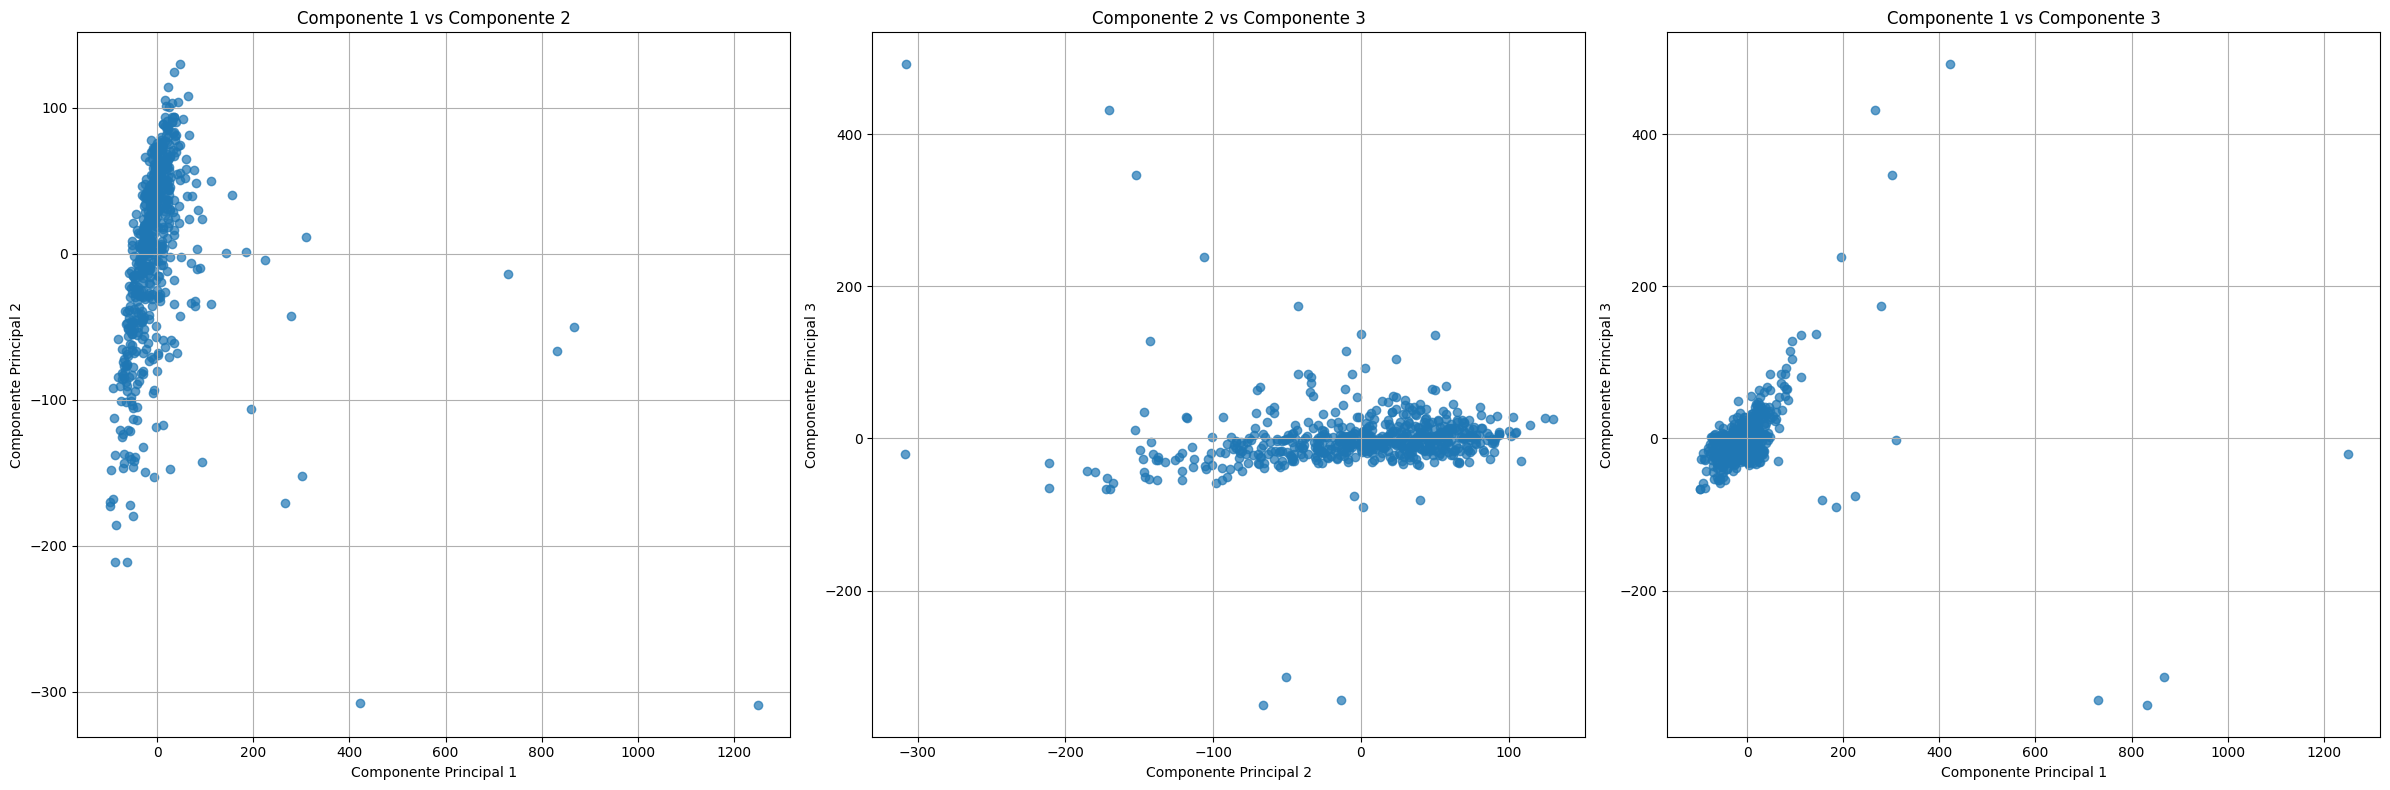

In [ ]:
plt.figure(figsize=(24, 8)) # Ajusta el tamaño para que las 3 gráficas quepan bien

# Componente 1 vs Componente 2
plt.subplot(1, 3, 1) # 1 fila, 3 columnas, primera gráfica
plt.scatter(pc_df['Componente 1'], pc_df['Componente 2'], alpha=0.7)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Componente 1 vs Componente 2')
plt.grid(True)

# Componente 2 vs Componente 3
plt.subplot(1, 3, 2) # 1 fila, 3 columnas, segunda gráfica
plt.scatter(pc_df['Componente 2'], pc_df['Componente 3'], alpha=0.7)
plt.xlabel('Componente Principal 2')
plt.ylabel('Componente Principal 3')
plt.title('Componente 2 vs Componente 3')
plt.grid(True)

# Componente 1 vs Componente 3
plt.subplot(1, 3, 3) # 1 fila, 3 columnas, tercera gráfica
plt.scatter(pc_df['Componente 1'], pc_df['Componente 3'], alpha=0.7)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 3')
plt.title('Componente 1 vs Componente 3')
plt.grid(True)

plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para que encajen en el área de la figura
plt.show()


En estas gráficas, no se observan agrupaciones claras, al menos no a simple vista. Parecería que casi todos los datos pertenecen a un mismo grupo. Esto tiene sentido con lo planteado anteriormente, donde se establece que es un conjunto de datos complejo y no se puede explicar con tan pocos componentes. Debido a que no se puede graficar y visualizar una figura con 353 dimensiones para identificar posibles clusters, se debe aplicar alguna técnica de clustering.


Se usarán 2 métodos (K-means y Hierarchical clustering) y se hará una comparación con los resultados.


El método K-means, de acuerdo con Ramírez (2024), es un algoritmo de aprendizaje no supervisado para agrupar un conjunto de datos en `k` clusters. Para este método, se debe seleccionar previamente este valor. Además, asume que los clusters son convexos, por lo que puede dificultársele identificar clusters de formas más complejas.


El método Hierarchical Clustering, de acuerdo con Chia (2025), es un aprendizaje no supervisado que sirve para agrupar puntos de datos similares en clusters. La agrupación jerárquica, como su nombre lo indica, construye una jerarquía multinivel juntando pequeños clusters a uno más grande o dividiendo clusters grandes en unos más pequeños. Este método arroja un diagrama similar a un árbol llamado dendrograma.


####**Método K-means**
Para este método, como ya se estableció, se debe seleccionar un valor de `k`. Sin embargo, debido a la complejidad de los datos, con tan sólo las gráficas que se construyeron hace rato no sirven para seleccionar un valor claro para la cantidad de agrupaciones. Existen diferentes métodos para encontrar el valor óptimo para `k`. Uno de ellos es el "Método del Codo", que de acuerdo con GeeksforGeeks (2025), es un método ampliamente usado ya que es simple de entender ya que se usa una técnica de visualización para ver esa estructura de codo. Es por eso que se usará este método para encontrar el valor óptimo para `k` para este caso. Esta técnica se basa en la idea es ver como la inercia* (costo) cambia conforme se aumenta el número de clusters.  
*Es la suma de la distancia al cuadrado de cada punto al centro del cluster que se le asignó. Entre más pequeña la inercia, mejor el agrupamiento.


Para este método, se debe graficar la inercia para diferentes valores de k (diferente cantidad de clusters). La idea es buscar un punto en la gráfica donde la disminución de la inercia se estabiliza, formando este codo. Este punto es considerado el óptimo valor de `k`.


Para hacer esto, se importa la librería Kmeans.
Se vuelve a correr el PCA con la cantidad de componentes que se estableció previamente (353). Luego se calcula la inercia para diferentes valores de k. Se elige explorar valores de k del 1 al 10. Luego se grafican estos puntos con `plt.plot` para encontrar el codo. Se establece una semilla de aleatoriedad a la hora de hacer los clusters para la reproducibilidad de los resultados.









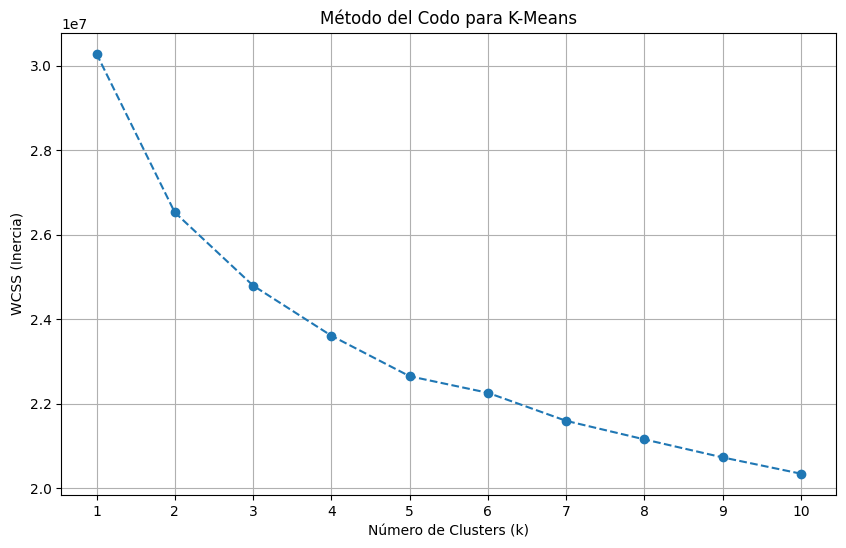

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Re-run PCA with 353 components to retain 90% of the variance
pca_final = PCA(n_components=353)
principal_components_final = pca_final.fit_transform(rna_seq_scaled_df)

# Calculate WCSS (Inertia) for different values of k
wcss = []
# Test k from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=1, n_init=10) # n_init is explicitly set
    kmeans.fit(principal_components_final)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Inercia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


El codo en esta gráfica no está tan marcado, pero se podría decir que está entre 2 y 3. Para este caso, se usará `k=3`.
Ya que tenemos este valor, se aplicará K-means a los datos transformados que retienen el 90% de la varianza, para agrupar a los pacientes en 3 clusters.





#### **Aplicando K-means con k=3**


Con base en el análisis del "Método del Codo", se ha determinado que `k=3` es un valor adecuado para el número de clusters. Ahora se aplicará el algoritmo K-means a los datos transformados por PCA (los `principal_components_final` que retienen el 90% de la varianza) para agrupar los pacientes en 3 clusters.


Se utilizará la función `KMeans` con `n_clusters=3` y `random_state` para asegurar la reproducibilidad de los resultados. Después de ajustar el modelo, se obtendrán las etiquetas de los clusters para cada paciente y se contará cuántos pacientes pertenecen a cada cluster. Se hace el mismo procedimiento que anteriormente, sólo que ahora sí se establece un valor para el número de clusters. De nuevo, se agrega una semilla de aleatoriedad y un número de iteraciones de 10.


Luego se agrega la columna `Clusters` para un análisis más sencillo, además de que se imprime la cantidad de datos que se asignaron a cada cluster, haciendo una suma para cada valor de cluster, son `[Cluster].value_counts()`. Además, se imprimen los primeros 10 valores con `head(10)`.





In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

# Perform K-means clustering with k=3
kmeans_model = KMeans(n_clusters=3, init='k-means++', random_state=1, n_init=10)
cluster_labels = kmeans_model.fit_predict(principal_components_final)

# Add the cluster labels to the original (transposed) DataFrame for easier analysis
rna_seq_df_transposed['Cluster'] = cluster_labels

print('Distribución de pacientes por cluster:')
display(rna_seq_df_transposed['Cluster'].value_counts())

print('\nPrimeros 10 pacientes con su etiqueta de cluster:')
display(rna_seq_df_transposed[['Cluster']].head(10))

Distribución de pacientes por cluster:


,count
Cluster,
0,360
1,221
2,4



Primeros 10 pacientes con su etiqueta de cluster:


Ensembl_ID,Cluster
TCGA-FI-A3PX-01A,0
TCGA-BG-A221-01A,0
TCGA-EY-A1GK-01A,0
TCGA-BG-A2AE-01A,0
TCGA-AX-A1CE-01A,0
TCGA-DI-A2QY-01A,1
TCGA-D1-A1O8-01A,1
TCGA-EY-A3QX-01A,0
TCGA-DI-A0WH-01A,1
TCGA-BK-A4ZD-01A,0


- Cluster 0: 360 pacientes
- Cluster 1: 221 pacientes
- Cluster 2: 4 pacientes


El cluster 2 es significativamente más pequeño que los otros 2. Esto podría indicar que estos 4 pacientes tienen rasgos fuera de lo común y es por eso que hay tan poco. Sin embargo, esto también podría indicar una mala elección en el número de clusters.


Ahora, para evaluar la calidad de los clusters, se usará la métrica coeficiente silueta. Esta métrica mide qué tan similar es un punto a su propio cluster en comparación con otros clusters. Un valor alto de este coeficiente indica que los objetos están bien emparejados con su propio cluster y bien separados de los demás. Este coeficiente va de -1 a 1. Para hacer esto, se importa la librería `sihouette_score` y se calcula con la función del mismo nombre y se le ingresan los valores de los componentes que se decidieron usar y las etiquetas de los clusters.Luego se imprime este valor. El valor será comparado con el obtenido para el clustering jerárquico.





In [ ]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score for K-means clustering
silhouette_avg_kmeans = silhouette_score(principal_components_final, cluster_labels)

print(f'El coeficiente de Silueta para el clustering K-means (k=3) es: {silhouette_avg_kmeans:.4f}')

El coeficiente de Silueta para el clustering K-means (k=3) es: 0.0580


El valor obtenido del coeficiente de Silueta para el clustering K-means fue de 0.0580, lo cual es un valor muy bajo, sugiriendo que los clusters no están muy bien separados. Esto también indica que los puntos no están fuertemente definidos al cluster al que fueron asignados. Una posible razón de un valor tan bajo es que el número de `k` no fue el correcto o el método no es el más adecuado. Es por eso que ahora se va a probar otro método de agrupamiento.


#### **Aplicando clustering jerárquico**
Para este método, primero se visualizará el dendograma para visualizar la estructura de lso datos y luego se aplicará el clustering con el número de clusters que se vea adecuado. Se debe elegir un método de enlace (linkage) y la métrica de distancia (metric). Para este caso, conviene usar como métrica la distancia euclidiana, debido a la compatibilidad con los datos transformados por PCA, que también se usa esta métrica, además que es ampliamente utilizada en problemas de clustering. Para el método de linkage, se usará el Ward, debido a que minimiza la varianza dentro de los clusters, generando grupos más compactos y homogéneos.


Para graficar el dendrograma, se importa la librería `AgglomerativeClustering`, además de `dendrogram` y `linkage`. Se crea la matriz de `linkage` con la función del mismo nombre. Luego se crea e imprime el dendograma con la función `dendrogram`, donde se establece que sólo muestre los últimos 50 clusters.





/tmp/ipykernel_7531/3899344692.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


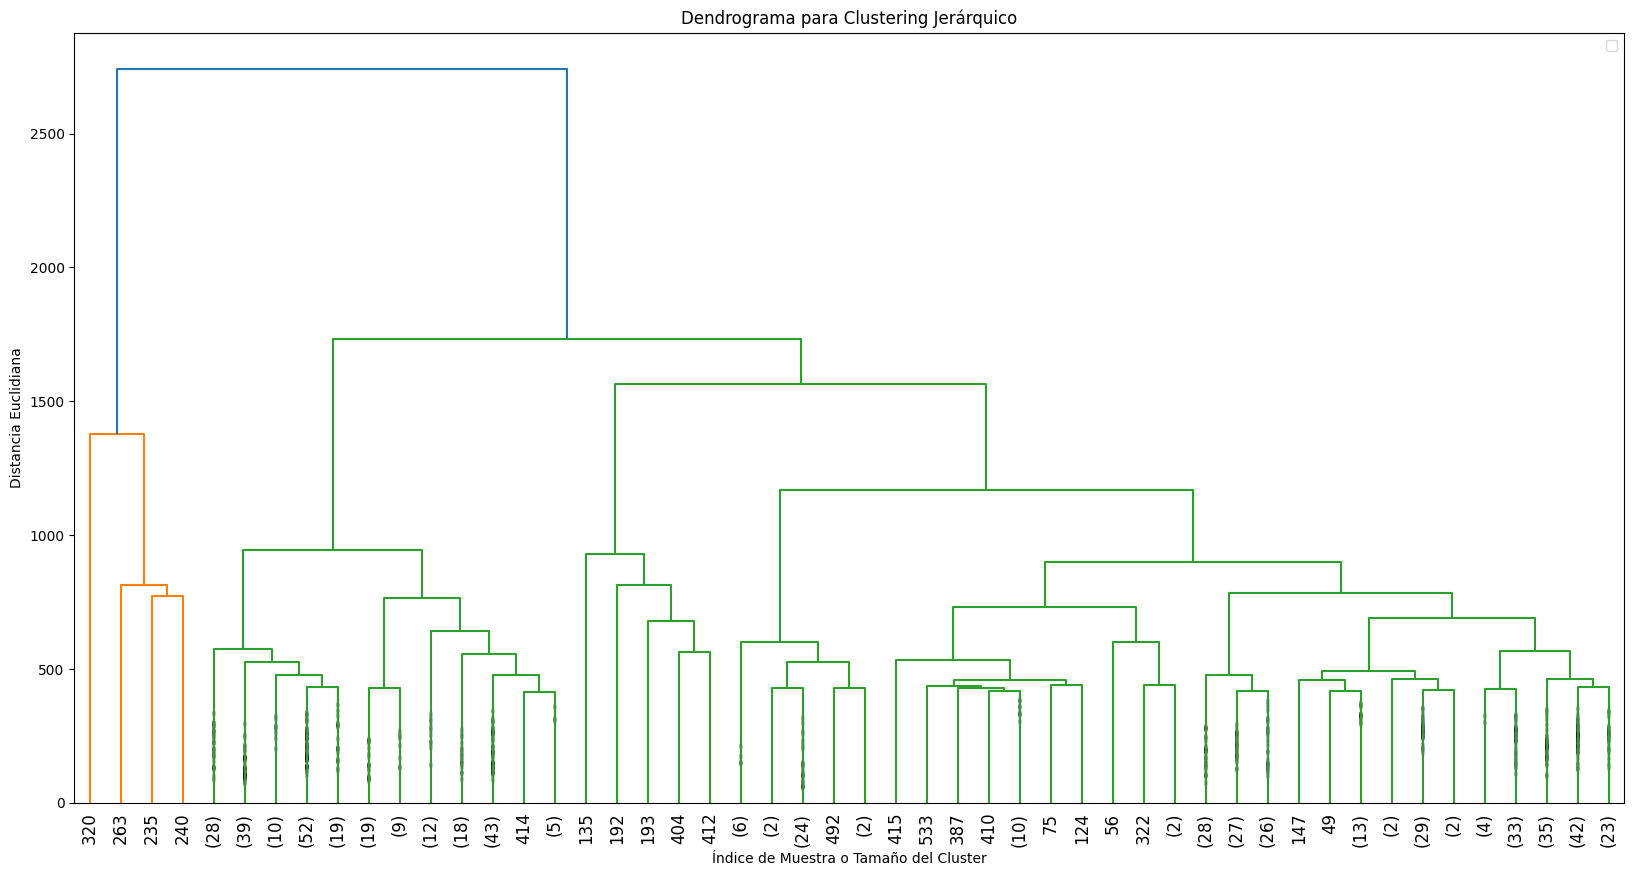

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# Generar la matriz de enlace para el dendrograma
# Usaremos 'ward' linkage ya que es comúnmente usado y funciona bien con la métrica euclidiana.
# linkage function works on the original data, not on the principal components if we want to see true distances.
# However, for consistency and performance, we will use the principal components.
linkage_matrix = linkage(principal_components_final, method='ward')

# Crear el dendrograma
plt.figure(figsize=(20, 10))
plt.title('Dendrograma para Clustering Jerárquico')
plt.xlabel('Índice de Muestra o Tamaño del Cluster')
plt.ylabel('Distancia Euclidiana')
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',  # Muestra solo los últimos p clusters unidos
    p=50,                  # Muestra los últimos 50 clusters
    show_leaf_counts=True,
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,
)
plt.legend()
plt.show()



Con este dendrograma, también se podrían identificar entre 2 y 3 clusters. Para fines comparativos, se usarán 3 clusters y se calculará el coeficiente de silueta. Se inicializa el modelo y luego se ajusta y predice el cluster para los componentes establecidos anteriormente.

Luego se imprimen la cantidad de datos que pertenecen a cada cluster.
finalmente se calcula el coeficiente de Silueta.

In [ ]:

n_clusters_hierarchical = 3

hierarchical_model = AgglomerativeClustering(n_clusters=n_clusters_hierarchical, linkage='ward')
cluster_labels_hierarchical = hierarchical_model.fit_predict(principal_components_final)

# Add the cluster labels to a new DataFrame for easier analysis (or to the existing transposed one)
rna_seq_df_transposed_hierarchical = rna_seq_df_transposed.copy()
rna_seq_df_transposed_hierarchical['Cluster_Hierarchical'] = cluster_labels_hierarchical

print('\nDistribución de pacientes por cluster (Clustering Jerárquico):')
display(rna_seq_df_transposed_hierarchical['Cluster_Hierarchical'].value_counts())

# Calcular el Coeficiente de Silueta para el Clustering Jerárquico
from sklearn.metrics import silhouette_score
silhouette_avg_hierarchical = silhouette_score(principal_components_final, cluster_labels_hierarchical)

print(f'\nEl coeficiente de Silueta para el clustering Jerárquico (k={n_clusters_hierarchical}) es: {silhouette_avg_hierarchical:.4f}')


Distribución de pacientes por cluster (Clustering Jerárquico):


,count
Cluster_Hierarchical,
0,326
2,255
1,4



El coeficiente de Silueta para el clustering Jerárquico (k=3) es: 0.0536


- Cluster 0: 326 pacientes
- Cluster 1: 255 pacientes
- Cluster 2: 4 pacientes


Estos valores son muy similares a los que se obtuvieron con el método anterior. El coeficiente de silueta fue de 0.0536, ligeramente menor al coeficiente calculado para el método de k-means.


Aunque K-means puede considerarse ligeramente superior en términos del coeficiente de silueta, la diferencia es muy pequeña, lo que podría indicar que ambos métodos presentan una calidad de clustering similar y limitada.


Por esto y para la mejor comprensión de los grupos que se crean, se utilizará el método de K-means.


Ahora, se van a identificar los genes que contribuyen a diferenciar los clusters obtenidos. Esto se hace con el fin de identificar genes que son un parte aguas para definir el cluster al que se asignan los pacientes. Se hará uso de ANOVA ya que se tiene 3 grupos, para encontrar si hay diferencia significativa en alguno de los grupos por cada gen. Dado que se están usando múltiples pruebas de hipótesis, lo cual expone a falsos descubrimientos, se debe ajustar los valores de p para controlarlo.


Se deben importar las librerías `f_oneway` y `multipletests`. Primero se preparan los datos, separando las expresiones génicas de las etiquetas de los clusters, usando la función `drop` para quitar la columna de los clusters. Luego se inicializan variables para los valores p y los nombres de los genes. Luego, para cada gen se compara el nivel de expresión entre el cluster 0, 1 y 2, usando un `for` loop. Luego se realiza la prueba ANOVA, en donde se estableció un valor de alpha de 0.05. Luego, para ajustar los valores de p obtenidos y reducir la tasa de falsos descubrimientos, se usa Benjamini-Hochberg. Este método permite reducir la probabilidad de marcar genes como significativos por azar.
Por último se ordenan los genes por los más significativos y se imprimen.







In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests
import pandas as pd

# Get the original gene expression data before adding cluster labels
# We need to make a copy to avoid modifying the original rna_seq_df_transposed that has the cluster column
gene_expression_data = rna_seq_df_transposed.drop(columns=['Cluster'])

# Get the cluster labels
cluster_labels = rna_seq_df_transposed['Cluster']

p_values = []
gene_names = []

# Iterate through each gene (column)
for gene in gene_expression_data.columns:
    # Get expression levels for each cluster
    expression_cluster0 = gene_expression_data.loc[cluster_labels == 0, gene]
    expression_cluster1 = gene_expression_data.loc[cluster_labels == 1, gene]
    expression_cluster2 = gene_expression_data.loc[cluster_labels == 2, gene]

    # Perform ANOVA only if there is data in all clusters
    if len(expression_cluster0) > 1 and len(expression_cluster1) > 1 and len(expression_cluster2) > 1:
        # Ensure there is variance within groups for ANOVA to be meaningful
        if expression_cluster0.var() > 0 or expression_cluster1.var() > 0 or expression_cluster2.var() > 0:
            f_stat, p_val = f_oneway(expression_cluster0, expression_cluster1, expression_cluster2)
            p_values.append(p_val)
            gene_names.append(gene)
    # Handle cases where one or more clusters have too few samples or no variance
    else:
        # Assign a p-value of 1 (not significant) if ANOVA cannot be performed
        p_values.append(1.0)
        gene_names.append(gene)

# Adjust p-values using Benjamini-Hochberg FDR correction
reject, p_values_adjusted, alphacSidak, alphacBonf = multipletests(p_values, alpha=0.05, method='fdr_bh')

# Create a DataFrame for results
differential_genes_df = pd.DataFrame({
    'Gene': gene_names,
    'P_Value': p_values,
    'P_Value_Adjusted': p_values_adjusted,
    'Significant_FDR': reject
})

# Filter for significant genes
significant_genes_df = differential_genes_df[differential_genes_df['Significant_FDR']].sort_values(by='P_Value_Adjusted').reset_index(drop=True)

print(f"Se encontraron {len(significant_genes_df)} genes con diferencias significativas (FDR < 0.05) entre los clusters.")
print('\nTop 10 genes con mayor significancia estadística:')
display(significant_genes_df.head(10))

Se encontraron 47638 genes con diferencias significativas (FDR < 0.05) entre los clusters.

Top 10 genes con mayor significancia estadística:


,Gene,P_Value,P_Value_Adjusted,Significant_FDR
0,ENSG00000240527.1,0.0,0.0,True
1,ENSG00000280190.1,0.0,0.0,True
2,ENSG00000253019.1,0.0,0.0,True
3,ENSG00000226056.1,0.0,0.0,True
4,ENSG00000230437.1,0.0,0.0,True
5,ENSG00000241295.1,0.0,0.0,True
6,ENSG00000164621.5,0.0,0.0,True
7,ENSG00000280348.1,0.0,0.0,True
8,ENSG00000273571.1,0.0,0.0,True
9,ENSG00000234886.1,0.0,0.0,True


Se encontraron 47638 genes con diferencias significativas que sirven para diferenciar entre clusters. En un inicio, se tenían 60,660 genes, lo cual indica que aproximadamente un 78% de los genes son significativos. Esto es un valor muy alto. Este no indica directamente un error, ya que si en los datos sí hay agrupaciones biológicas, entonces esto ayudaría a reforzarlo.


Ahora, para ver si estos clusters tienen relevancia en el mundo real, se hará un análisis de las variables clínicas obtenidas para identificar posibles relaciones con los clusters. Para esto, se usará el archivo `TCGA-UCEC.clinical.tsv.gz`, obtenido del mismo sitio. Se comienza por cargar los datos al espacio de trabajo, con la función `read_csv`, Luego se imprimen las primeras 5 filas y las dimensiones de la base de datos. También se imprime la suma de los distintos tipos de variable, además de las variables que pertenecen a ese tipo.









In [ ]:
clinical_df = pd.read_csv('/content/TCGA-UCEC.clinical.tsv.gz', sep='\t')
print('Datos clínicos (primeras 5 filas):')
display(clinical_df.head())
print('Dimensiones de la base de datos clínica: ', clinical_df.shape)

Datos clínicos (primeras 5 filas):


,sample,id,disease_type,case_id,submitter_id,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,...,sample_type.samples,composition.samples,days_to_collection.samples,initial_weight.samples,preservation_method.samples,pathology_report_uuid.samples,oct_embedded.samples,specimen_type.samples,is_ffpe.samples,tissue_type.samples
0,TCGA-AJ-A3NC-01A,c8fb94dd-c535-48f4-9419-aac2bf47bbb4,Adenomas and Adenocarcinomas,c8fb94dd-c535-48f4-9419-aac2bf47bbb4,TCGA-AJ-A3NC,Corpus uteri,Not Reported,white,female,not reported,...,Primary Tumor,Not Reported,282.0,300.0,Unknown,B6DB87F4-E88A-4209-92E2-75ADB364FB28,False,Solid Tissue,False,Tumor
1,TCGA-AJ-A3NC-11A,c8fb94dd-c535-48f4-9419-aac2bf47bbb4,Adenomas and Adenocarcinomas,c8fb94dd-c535-48f4-9419-aac2bf47bbb4,TCGA-AJ-A3NC,Corpus uteri,Not Reported,white,female,not reported,...,Solid Tissue Normal,Not Reported,282.0,70.0,Unknown,NaN,False,Solid Tissue,False,Normal
2,TCGA-KP-A3W0-01A,c9ebaeff-6a27-4a6c-a34c-5337a3508a52,"Cystic, Mucinous and Serous Neoplasms",c9ebaeff-6a27-4a6c-a34c-5337a3508a52,TCGA-KP-A3W0,Corpus uteri,Not Reported,not reported,female,not reported,...,Primary Tumor,Not Reported,351.0,90.0,OCT,8623B627-C3E3-469B-A640-2F8BCFC0B711,True,Solid Tissue,False,Tumor
3,TCGA-B5-A11N-01A,ca594f56-9c68-4b7e-84b2-669f1004e3a4,Adenomas and Adenocarcinomas,ca594f56-9c68-4b7e-84b2-669f1004e3a4,TCGA-B5-A11N,Corpus uteri,Not Reported,white,female,not reported,...,Primary Tumor,Not Reported,1140.0,370.0,OCT,A4C1DE15-A45A-4D31-B363-C6652370C09C,True,Solid Tissue,False,Tumor
4,TCGA-BS-A0V7-01A,ca858743-1f06-40e3-accf-395d08375b63,Adenomas and Adenocarcinomas,ca858743-1f06-40e3-accf-395d08375b63,TCGA-BS-A0V7,Corpus uteri,Not Reported,native hawaiian or other pacific islander,female,not hispanic or latino,...,Primary Tumor,Not Reported,1455.0,130.0,Unknown,A4515806-9888-48E8-8F9E-491527FFC29C,False,Solid Tissue,False,Tumor


Dimensiones de la base de datos clínica:  (600, 79)


In [ ]:

# Separate numerical and categorical columns
numerical_cols = clinical_df.select_dtypes(include=['number']).columns
categorical_cols = clinical_df.select_dtypes(include=['object', 'bool']).columns

print(f"\nNúmero de variables numéricas: {len(numerical_cols)}")
print("Variables numéricas:")
for col in numerical_cols:
    print(f"- {col} ({clinical_df[col].dtype})")

print(f"\nNúmero de variables categóricas: {len(categorical_cols)}")
print("Variables categóricas:")
for col in categorical_cols:
    print(f"- {col} ({clinical_df[col].dtype})")



Número de variables numéricas: 14
Variables numéricas:
- age_at_index.demographic (float64)
- days_to_birth.demographic (float64)
- year_of_birth.demographic (float64)
- year_of_death.demographic (float64)
- days_to_death.demographic (float64)
- days_to_diagnosis.diagnoses (float64)
- days_to_last_follow_up.diagnoses (float64)
- age_at_diagnosis.diagnoses (float64)
- year_of_diagnosis.diagnoses (float64)
- age_at_earliest_diagnosis.diagnoses.xena_derived (float64)
- age_at_earliest_diagnosis_in_years.diagnoses.xena_derived (float64)
- sample_type_id.samples (int64)
- days_to_collection.samples (float64)
- initial_weight.samples (float64)

Número de variables categóricas: 65
Variables categóricas:
- sample (object)
- id (object)
- disease_type (object)
- case_id (object)
- submitter_id (object)
- primary_site (object)
- alcohol_history.exposures (object)
- race.demographic (object)
- gender.demographic (object)
- ethnicity.demographic (object)
- vital_status.demographic (object)
- prim

Como se puede ver, esta base de datos tiene 600 observaciones y 79 variables. Este conjunto de datos tiene más observaciones que el conjunto de la expresión génica, por lo que se tendrá que hacer un búsqueda del número de muestra en ambos conjuntos para eliminar todos los que sólo pertenezcan a un conjunto.


Además, se puede decir que hay 14 variables numéricas, como el peso inicial, edad cuando se le diagnosticó, etc.
También se cuenta con 65 variables categóricas, como género, grado del tumor, etc.


Para hacer el análisis entre las variables clínicas y los clusters creados, se va integrar las etiquetas de los clusters a los datos clínicos. Esto se hará usando la función `merge`, usando inner merge para sólo mantener los datos qué sí estaban en la base de datos anterior.





In [ ]:
# Reset index of rna_seq_df_transposed to make 'sample' a column for merging
rna_seq_clusters_df = rna_seq_df_transposed[['Cluster']].reset_index()
rna_seq_clusters_df.rename(columns={'index': 'sample'}, inplace=True)

# Merge clinical data with cluster assignments
# We'll use 'sample' from rna_seq_clusters_df and 'sample' from clinical_df
# Note: clinical_df might have more samples than rna_seq_df, so we'll do an inner merge
merged_clinical_clusters_df = pd.merge(clinical_df, rna_seq_clusters_df, on='sample', how='inner')

print(f"Dimensiones de los datos clínicos fusionados con clusters: {merged_clinical_clusters_df.shape}")
print("Primeras 5 filas de los datos fusionados:")
display(merged_clinical_clusters_df.head())

# Check how many samples were matched
print(f"Número de muestras con datos de expresión génica y datos clínicos: {len(merged_clinical_clusters_df)}")

Dimensiones de los datos clínicos fusionados con clusters: (585, 80)
Primeras 5 filas de los datos fusionados:


,sample,id,disease_type,case_id,submitter_id,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,...,composition.samples,days_to_collection.samples,initial_weight.samples,preservation_method.samples,pathology_report_uuid.samples,oct_embedded.samples,specimen_type.samples,is_ffpe.samples,tissue_type.samples,Cluster
0,TCGA-AJ-A3NC-01A,c8fb94dd-c535-48f4-9419-aac2bf47bbb4,Adenomas and Adenocarcinomas,c8fb94dd-c535-48f4-9419-aac2bf47bbb4,TCGA-AJ-A3NC,Corpus uteri,Not Reported,white,female,not reported,...,Not Reported,282.0,300.0,Unknown,B6DB87F4-E88A-4209-92E2-75ADB364FB28,False,Solid Tissue,False,Tumor,0
1,TCGA-AJ-A3NC-11A,c8fb94dd-c535-48f4-9419-aac2bf47bbb4,Adenomas and Adenocarcinomas,c8fb94dd-c535-48f4-9419-aac2bf47bbb4,TCGA-AJ-A3NC,Corpus uteri,Not Reported,white,female,not reported,...,Not Reported,282.0,70.0,Unknown,NaN,False,Solid Tissue,False,Normal,0
2,TCGA-KP-A3W0-01A,c9ebaeff-6a27-4a6c-a34c-5337a3508a52,"Cystic, Mucinous and Serous Neoplasms",c9ebaeff-6a27-4a6c-a34c-5337a3508a52,TCGA-KP-A3W0,Corpus uteri,Not Reported,not reported,female,not reported,...,Not Reported,351.0,90.0,OCT,8623B627-C3E3-469B-A640-2F8BCFC0B711,True,Solid Tissue,False,Tumor,0
3,TCGA-B5-A11N-01A,ca594f56-9c68-4b7e-84b2-669f1004e3a4,Adenomas and Adenocarcinomas,ca594f56-9c68-4b7e-84b2-669f1004e3a4,TCGA-B5-A11N,Corpus uteri,Not Reported,white,female,not reported,...,Not Reported,1140.0,370.0,OCT,A4C1DE15-A45A-4D31-B363-C6652370C09C,True,Solid Tissue,False,Tumor,1
4,TCGA-BS-A0V7-01A,ca858743-1f06-40e3-accf-395d08375b63,Adenomas and Adenocarcinomas,ca858743-1f06-40e3-accf-395d08375b63,TCGA-BS-A0V7,Corpus uteri,Not Reported,native hawaiian or other pacific islander,female,not hispanic or latino,...,Not Reported,1455.0,130.0,Unknown,A4515806-9888-48E8-8F9E-491527FFC29C,False,Solid Tissue,False,Tumor,1


Número de muestras con datos de expresión génica y datos clínicos: 585


El número de muestras en el DataFrame fusionado (`merged_clinical_clusters_df`) coincide con el número de pacientes en los datos de expresión génica (585). Esto significa que sí se emparejó de mnaera exitosa los datos de expresión génica y los datos clínicos de los pacientes.

Ahora, se hará el análisis por cluster.
Para las variables cateróricas, se realizará un análisis de varianza ANOVA para cada una de las variables. Esto permitirá determinar si las diferencias observadas en las medias de estas variables entre los clusters son estadísticamente significativos. Al igual que en pasos anteriores, se aplicará Benjamini-Hochberg para controlar la tasa de falsos descubrimientos. El método y funciones utilizadas es igual que en la prueba ANOVA antrior.

Luego se agrega una línea de código que imprime las variables donde las medias entre clusters sí son significativamente difernetes.

In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multitest import multipletests

# Get all numerical columns from the merged DataFrame, excluding the 'Cluster' column
all_numerical_vars = merged_clinical_clusters_df.select_dtypes(include=['number']).columns.drop('Cluster')

p_values_num = []
variable_names_num = []

print("\nAnálisis ANOVA para TODAS las Variables Numéricas por Cluster:")
for col in all_numerical_vars:
    # Extract data for each cluster
    data_cluster0 = merged_clinical_clusters_df[merged_clinical_clusters_df['Cluster'] == 0][col].dropna()
    data_cluster1 = merged_clinical_clusters_df[merged_clinical_clusters_df['Cluster'] == 1][col].dropna()
    data_cluster2 = merged_clinical_clusters_df[merged_clinical_clusters_df['Cluster'] == 2][col].dropna()

    # Perform ANOVA only if all clusters have sufficient data (more than 1 non-NaN value) and variance
    if len(data_cluster0) > 1 and len(data_cluster1) > 1 and len(data_cluster2) > 1:
        # Check if there is variance within at least one group for ANOVA to be valid
        if data_cluster0.var() > 0 or data_cluster1.var() > 0 or data_cluster2.var() > 0:
            f_stat, p_val = f_oneway(data_cluster0, data_cluster1, data_cluster2)
            p_values_num.append(p_val)
            variable_names_num.append(col)
        else:
            # If no variance within groups, ANOVA is not meaningful. P-value set to 1.0
            p_values_num.append(1.0)
            variable_names_num.append(col)
    else:
        # If not enough data in all clusters, ANOVA cannot be performed. P-value set to 1.0
        p_values_num.append(1.0)
        variable_names_num.append(col)

# Adjust p-values using Benjamini-Hochberg FDR correction
if p_values_num:
    reject_num, p_values_adjusted_num, _, _ = multipletests(p_values_num, alpha=0.05, method='fdr_bh')

    # Create a DataFrame for results
    anova_results_df_num = pd.DataFrame({
        'Variable': variable_names_num,
        'P_Value': p_values_num,
        'P_Value_Adjusted_FDR': p_values_adjusted_num,
        'Significant_FDR_0.05': reject_num
    })
    print("\nResultados ANOVA (con corrección Benjamini-Hochberg):")
    display(anova_results_df_num)

    significant_vars = anova_results_df_num[anova_results_df_num['Significant_FDR_0.05'] == True]

    if not significant_vars.empty:
        print("\nVariables numéricas estadísticamente significativas (FDR < 0.05) entre clusters:")
        display(significant_vars.sort_values(by='P_Value_Adjusted_FDR'))
    else:
        print("\nNo se encontraron variables numéricas estadísticamente significativas (FDR < 0.05) entre los clusters.")

else:
    print("No se pudieron realizar pruebas ANOVA para ninguna variable numérica.")


Análisis ANOVA para TODAS las Variables Numéricas por Cluster:

Resultados ANOVA (con corrección Benjamini-Hochberg):


,Variable,P_Value,P_Value_Adjusted_FDR,Significant_FDR_0.05
0,age_at_index.demographic,0.452070,0.726240,False
1,days_to_birth.demographic,0.466868,0.726240,False
2,year_of_birth.demographic,0.824677,1.000000,False
3,year_of_death.demographic,1.000000,1.000000,False
4,days_to_death.demographic,1.000000,1.000000,False
5,days_to_diagnosis.diagnoses,1.000000,1.000000,False
6,days_to_last_follow_up.diagnoses,0.023420,0.097096,False
7,age_at_diagnosis.diagnoses,0.466868,0.726240,False
8,year_of_diagnosis.diagnoses,0.000304,0.002128,True
9,age_at_earliest_diagnosis.diagnoses.xena_derived,0.466868,0.726240,False



Variables numéricas estadísticamente significativas (FDR < 0.05) entre clusters:


,Variable,P_Value,P_Value_Adjusted_FDR,Significant_FDR_0.05
11,sample_type_id.samples,0.000039,0.000544,True
8,year_of_diagnosis.diagnoses,0.000304,0.002128,True


Las únicas 2 variables que sí muestran una diferencia significativa para diferenciar entre clusters fueron `sample_type_id.samples` y `year_of_diagnosis.diagnoses`.


Ahora, para las variables categóricas, se utiliza la prueba de significancia Chi-cuadrado. También se aplicará Benjamini-Hochberg para la corrección de valor de p. Para esto, se necesita importar la librería `chi2_contingency`.  Se excluyen todas las variables categóricas que tienen valores únicos (como el ID del paciente), ya que no tendría sentido tratar de encontrar agrupaciones cuando se tienen múltiples categorías. De igual manera, se corrigen los valores de p y se imprimen las variables que sí muestran una diferencia significativa.





In [ ]:
from scipy.stats import chi2_contingency

# Get all categorical columns from the merged DataFrame
all_categorical_vars = merged_clinical_clusters_df.select_dtypes(include=['object', 'bool']).columns

# Define columns to exclude from chi-squared test (e.g., IDs, timestamps, or variables with too many unique values)
# These columns are unlikely to yield meaningful results in a cluster comparison or could cause errors due to sparse tables.
categorical_cols_to_exclude = [
    'sample', 'id', 'case_id', 'submitter_id', 'pathology_report_uuid.samples',
    'entity_submitter_id.annotations', 'notes.annotations', 'submitter_id.annotations',
    'entity_id.annotations', 'created_datetime.annotations', 'annotation_id.annotations',
    'updated_datetime.annotations', 'case_id.annotations', 'case_submitter_id.annotations',
    'updated_datetime.treatments.diagnoses', 'treatment_id.treatments.diagnoses',
    'submitter_id.treatments.diagnoses', 'created_datetime.treatments.diagnoses',
    'sample_id.samples',
    'name.project', 'name.program.project', 'project_id.project',
    'name.tissue_source_site', 'project.tissue_source_site', 'bcr_id.tissue_source_site',
    'icd_10_code.diagnoses', # Often too many unique codes for meaningful chi-squared
    'morphology.diagnoses', # Often too many unique values
    'site_of_resection_or_biopsy.diagnoses' # Often too many unique values
]

# Filter out excluded columns
categorical_vars_for_analysis = [col for col in all_categorical_vars if col not in categorical_cols_to_exclude]

p_values_cat = []
variable_names_cat = []

print("\nAnálisis Chi-cuadrado para Variables Categóricas por Cluster:")
for col in categorical_vars_for_analysis:
    # Create a contingency table
    contingency_table = pd.crosstab(merged_clinical_clusters_df['Cluster'], merged_clinical_clusters_df[col])

    # Only proceed if the table is not empty and has more than 1 row/column for chi-squared
    if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
        # Check for columns that are constant (only one unique value, or all NaNs)
        if merged_clinical_clusters_df[col].nunique() > 1:
            try:
                chi2, p_val, _, _ = chi2_contingency(contingency_table)
                p_values_cat.append(p_val)
                variable_names_cat.append(col)
            except ValueError: # Catch cases where chi2_contingency might fail (e.g., very sparse tables)
                p_values_cat.append(1.0) # Not significant
                variable_names_cat.append(col)
        else:
            # If the column has only one unique value, it cannot differentiate clusters
            p_values_cat.append(1.0) # Not significant
            variable_names_cat.append(col)
    else:
        # If contingency table is too small or constant, chi-squared is not applicable
        p_values_cat.append(1.0) # Not significant
        variable_names_cat.append(col)

# Adjust p-values using Benjamini-Hochberg FDR correction
if p_values_cat:
    reject_cat, p_values_adjusted_cat, _, _ = multipletests(p_values_cat, alpha=0.05, method='fdr_bh')

    # Create a DataFrame for results
    chi2_results_df_cat = pd.DataFrame({
        'Variable': variable_names_cat,
        'P_Value': p_values_cat,
        'P_Value_Adjusted_FDR': p_values_adjusted_cat,
        'Significant_FDR_0.05': reject_cat
    })
    print("\nResultados Chi-cuadrado (con corrección Benjamini-Hochberg):")
    display(chi2_results_df_cat)

    significant_vars_cat = chi2_results_df_cat[chi2_results_df_cat['Significant_FDR_0.05'] == True]

    if not significant_vars_cat.empty:
        print("\nVariables categóricas estadísticamente significativas (FDR < 0.05) entre clusters:")
        display(significant_vars_cat.sort_values(by='P_Value_Adjusted_FDR'))
    else:
        print("\nNo se encontraron variables categóricas estadísticamente significativas (FDR < 0.05) entre los clusters.")

else:
    print("No se pudieron realizar pruebas Chi-cuadrado para ninguna variable categórica.")


Análisis Chi-cuadrado para Variables Categóricas por Cluster:

Resultados Chi-cuadrado (con corrección Benjamini-Hochberg):


,Variable,P_Value,P_Value_Adjusted_FDR,Significant_FDR_0.05
0,disease_type,4.327434e-03,2.001438e-02,True
1,primary_site,9.525166e-02,3.203919e-01,False
2,alcohol_history.exposures,1.000000e+00,1.000000e+00,False
3,race.demographic,3.324551e-01,7.688024e-01,False
4,gender.demographic,1.000000e+00,1.000000e+00,False
5,ethnicity.demographic,3.326532e-02,1.367574e-01,False
6,vital_status.demographic,7.435187e-01,1.000000e+00,False
7,primary_site.project,1.000000e+00,1.000000e+00,False
8,disease_type.project,1.000000e+00,1.000000e+00,False
9,tissue_source_site_id.tissue_source_site,5.483928e-14,5.072634e-13,True



Variables categóricas estadísticamente significativas (FDR < 0.05) entre clusters:


,Variable,P_Value,P_Value_Adjusted_FDR,Significant_FDR_0.05
35,is_ffpe.samples,9.308164e-128,3.444021e-126,True
32,preservation_method.samples,2.731858e-125,5.053937e-124,True
9,tissue_source_site_id.tissue_source_site,5.483928e-14,5.072634e-13,True
10,code.tissue_source_site,5.483928e-14,5.072634e-13,True
36,tissue_type.samples,4.678131e-05,3.461817e-04,True
29,tumor_descriptor.samples,3.728247e-04,1.970645e-03,True
30,sample_type.samples,3.728247e-04,1.970645e-03,True
0,disease_type,4.327434e-03,2.001438e-02,True


De las variables categóricas, las que mostraron diferencias significativas fueron:
- `is_ffpe.samples` (si la muestra fue fijada en formalina y embebida en parafina)
- `preservation_method.samples`
- ` tissue_source_site_id.tissue_source_site`
- `code.tissue_source_site`
- `tissue_type.samples`
- `tumor_descriptor.samples`
- `sample_type.samples`
- `disease_type`


Tanto las variables numéricas que se identificaron como significativas, como las variables categóricas, no tienen que ver directamente con las características clínicas del paciente, sino de características técnicas y del origen de la muestra. Esto significa que los clusters están influenciados por estos factores. Por lo tanto, con este análisis se puede decir que los clusters encontrados no representan necesariamente subgrupos clínicamente diferenciados de pacientes.


El hecho de que se haya identificado el tipo de muestra y el año de diagnóstico son características clínicas que varían significativamente entre los grupos de pacientes identificados por el clustering que se realizó anteriormente con la expresión génica, al igual que otras variables de este estilo, podría indicar que no se está eliminando por completo el sesgo que puede surgir por tomar y analizar las muestras en diferentes establecimientos, con posiblemente diferentes equipos y con diferentes tecnologías que van cambiando con los años.


A continuación, se hará un comparación metodológica y de resultados de un estudio realizado por Roque et al. (2016) donde el objetivo era evaluar las diferencias en los distintos perfiles de expresión génica de mujeres con y sin obesidad y después se analizó la asociación del índice de masa corporal (IMC) dentro de los clusters que TCGA identificó dentro del cáncer de endometrio.


En ese artículo, se usaron los datos de TCGA RNA seq para identificar los genes relacionados con el incremento de IMC en mujeres con cáncer de endometrio. El IMC se comparó entre los 3 clusters usando la prueba estadística ANOVA de un factor. También se hizo un análisis de la relación entre la expresión de los genes y el IMC, tomando en cuenta otros factores que podrían influir en los resultados. Además, los p values se ajustaron para reducir los errores tipo I debido a la gran cantidad de genes analizados (20,531).


Después de realizar este análisis, encontraron que el IMC promedio fue significativamente diferente entre los cánceres del grupo CNL (35.8) y el grupo POLE (29.8) ($p=0.006$). También estuvo cerca de ser significativo al comparar el grupo de MSI (33.0) y CNL (35.8) ($p=0.05$).


En este estudio se identificaron 181 genes cuya expresion aumentó o disminuyó significativamente conforme aumentaba el IMC ($q < 0.01$), incluyendo los genes LPL, IRS-1, IGFBP4, IGFBP7 y el receptor de progesterona.


Concluyen que los genes relacionados con la obesidad se encontraron más activos a medida que aumentaba el IMC en los carcinomas endometrioides de endometrio. Las pacientes con tumores con mutaciones en POLE presentan el IMC más bajo en comparación con los subtipos MSI y CNL. También proponen que dada la heterogeneidad entre los carcinomas endometrioide debería abandonarse la clasificación tradicional de tumores de endometrio en Tipo I y Tipo II.


A continuación, se establecen algunos de los acrónimos usando en el resumen:


- CNL -> Copy-Number Low (Tumores con bajos cambios en el número de copias de ADN)


- Pole -> Subtipo de mutaciones en el gen POLE


- MSI -> MIcrosatellite Instability (Tumores con inestabilidad de microsatélites; problemas en reparación del ADN)




Ahora, se hará una comparación directa entre este artículo y el reporte presente.


**Similitudes**


- Se usa el mismo tipo de cáncer.
- Se realizan pruebas ANOVA para encontrar variables significativamente diferentes.
- Se realiza una corrección del p-value para bajar la cantidad de falsos positivos.
- Se usa Benjamini-Hochberg para corregir el p-value.
- En ambos se utilizan 3 clusters.




**Diferencias**
- En el artículo de referencia se usan los datos `IlluminaGA RNA-seq level 3`, mientras que en este se usa `STAR - TPM`.
- En el artículo de referencia se trabaja con 20,531 genes y en este se trabajan con 60660 genes.
- El método de clustering es diferente. En el de referencia es el hierarchical clustering mientras que en este es el K-means clustering.
- En el artículo de referencia se usa un valor de alpha de 0.01, mientras que en el presente se usa un valor de 0.05.
- En el presente reporte se analizan las variables clínicas del paciente, para identificar posibles clusters. Mientras que en el reporte de referencia se analiza únicamente el IMC.


Aunque ya se mencionaron los resultados del reporte de referencia, no se puede hacer una comparación directa ya que se analizan cosas diferentes.


####**Conclusión**


Una de las limitaciones que se presenta en este reporte es que hay una ausencia de conocimiento técnico que podría ayudar a dar una mayor interpretación a los resultados obtenidos. Además, otra limitante que se tiene es que debido a la cantidad de variables que se tienen (genes) es imposible poder visualizarlos gráficamente para determinar con cuántos clusters trabajar. En este caso, a partir de diferentes análisis, se optó por hacer 3 clusters. Sin embargo, puede ser que haya algún otro valor que también ayude a encontrar resultados relevantes. Sobre esta misma línea, una vez aplicado el PCA también se elige manualmente la cantidad de componentes con los que se desea trabajar, por lo que también podría haber variación de resultados en caso de que se elija otro porcentaje.


Otra limitante es que, como se observó tras realizar el análisis de PCA, no fue posible reducir significativamente la dimensionalidad de los datos sin perder una parte considerable de la información. Esto podría deberse a la complejidad inherente de los datos y a la baja correlación entre las variables, volviendo el proceso más complejo.




Se propone para trabajos futuros explorar otros tipo de clustering, trabajándolos hasta el final para poder hacer una comparación de los grupos que se identificaron y cuáles podrían contribuir más al objetivo que se tenga del proyecto. Además, se propone apoyarse con especialistas en el tema para dar mayor interpretación a los resultados o descubrir cosas que al ojo de un no experto pudieran pasar desapercibidas. Por último, también se propone trabajar al mismo tiempo con distintos tipos de cáncer asociados con un género (como cáncer de mama, cáncer de endometrio, cáncer de útero, etc.) para ver si se pueden encontrar clusters que podrían ayudar a identificar patrones que ayuden a mejorar los tratamientos o las detecciones tempranas de estos tipos de cáncer.


Con base a la estructura de los datos analizados, el PCA mostró que las expresiones génicas para el cáncer de endometrio presentan una complejidad mayor a la esperada. Además, no se observó una separación clara entre las muestras ni una correlación fuerte entre las variables principales, lo que sugiere que la variabilidad de los datos no puede explicarse fácilmente mediante un número reducido de componentes principales.


Después, mediante el algoritmo de k-means y utilizando el método del codo, se identificaron 3 clusters principales en los que se podían separar los datos. Sin embargo, al comparar estos grupos con las variables clínicas de los pacientes se observó que las variables significativas asociadas con los clusters fueron las siguientes:


- `is_ffpe.samples`
- `preservation_method.samples`
- ` tissue_source_site_id.tissue_source_site`
- `code.tissue_source_site`
- `tissue_type.samples`
- `tumor_descriptor.samples`
- `sample_type.samples`
- `disease_type`
- `sample_type_id.samples`
- `year_of_diagnosis.diagnoses`


Estas variables están relacionadas principalmente con aspectos técnicos y de procesamiento de las muestras, como el método de preservación, el sitio de origen del tejido, el tipo de muestra, el año de diagnóstico, más que con características clínicas o biológicas de los pacientes.


Por esto mismo, los resultados podrían indicar que los clusters identificados reflejan principalmente diferencias técnicas en la obtención y procesamiento de las muestras, en lugar de clusters biológicos asociados al cáncer o estado clínico de los pacientes. Esto podría indicar que existe la presencia del batch effect (de acuerdo con Wikipedia contributors (2025), es cuando factores no biológicos en un experimento causan cambios en los datos producidos para el experimento) o variaciones sistemáticas debido a las diferencias de protocolos, tecnologías utilizadas o condiciones de almacenamiento y procesamiento de las muestras.


Debido a esto, también se propone aplicar métodos adicionales de normalización o corrección del batch effect antes de realizar nuevamente el análisis de clustering, con el objetivo de identificar patrones biológicamente relevantes y reducir la influencia de factores técnicos sobre la estructura de los datos.

















---
**Referencias**:
- Endometrial cancer statistics | World Cancer Research Fund. (2025, July 28). World Cancer Research Fund. https://www.wcrf.org/preventing-cancer/cancer-statistics/endometrial-cancer-statistics/
- Estadísticas clave del cáncer de endometrio | American Cancer Society. (n.d.). American Cancer Society. https://www.cancer.org/es/cancer/tipos/cancer-de-endometrio/acerca/estadisticas-clave.html
- Cáncer de endometrio - Síntomas y causas - Mayo Clinic. (n.d.). https://www.mayoclinic.org/es/diseases-conditions/endometrial-cancer/symptoms-causes/syc-20352461
- EBI Functional Genomics Team – https://www.ebi.ac.uk/people/person/christina-ernst. (n.d.). Help page < Expression Atlas < EMBL-EBI. https://www.ebi.ac.uk/gxa/help/index.html
- Ramírez, L. (2024, October 30). Algoritmo k-means: ¿Qué es y cómo funciona? Thinking for Innovation. https://www.iebschool.com/hub/algoritmo-k-means-que-es-y-como-funciona-big-data/
- Chia, A. (2025, April 28). Agrupación jerárquica: Concepto general con ejemplos. https://www.datacamp.com/es/tutorial/hierarchical-clustering
- GeeksforGeeks. (2025, July 11). Determine the optimal value of K in KMeans Clustering ML. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/ml-determine-the-optimal-value-of-k-in-k-means-clustering/
- Roque, D. R., Makowski, L., Chen, T., Rashid, N., Hayes, D. N., & Bae-Jump, V. (2016). Association between differential gene expression and body mass index among endometrial cancers from The Cancer Genome Atlas Project. Gynecologic Oncology, 142(2), 317–322. https://doi.org/10.1016/j.ygyno.2016.06.006
- Wikipedia contributors. (2025, October 17). Batch effect. Wikipedia. https://en.wikipedia.org/wiki/Batch_effect

**Código de Honor**: Doy mi palabra que he realizado esta actividad con integridad académica.  

Se implementó el uso de IA unicamente para dudas de redacción y código.